In [1]:
#1 Data Preparation 

import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/q2_customers.csv')

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data,columns=df.columns)

## why scaling is essential before applying K-Means?

K-Means clustering is a distance-based algorithm that relies on Euclidean distance. If features are on different scales, variables with larger values will dominate the distance calculation.

Scaling standardizes all features so they contribute equally to the clustering process.

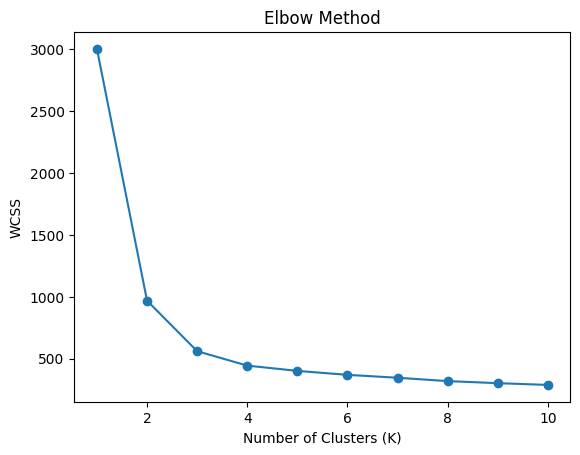

In [2]:
#2 Choosing K — Elbow Method 

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

##  Identify the optimal K from the elbow point and justify your selection.

The elbow point is where the decrease in WCSS starts to slow down significantly.

From the plot, the elbow occurs at K = 3 (adjust based on your graph). Therefore, K = 3 is chosen as the optimal number of clusters.

In [4]:
#3  K-Means Clustering 

optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_data)

# Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

print(centroids)

         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


##  K-Means Clustering 

Cluster 0: Young customers with frequent visits and low spending.

Cluster 1: High spending customers with large basket sizes.

Cluster 2: Infrequent customers with long gaps between visits.

In [5]:
#4 Dimensionality Reduction with PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

print("Explained Variance:", pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

print(loadings)

Explained Variance: [0.83560354 0.05568764]
          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


## Dimensionality Reduction with PCA

PC1 represents overall spending behavior as it is influenced by features like annual_spend and basket_size.

PC2 represents customer engagement, influenced by visits_per_month and days_since_last_visit.

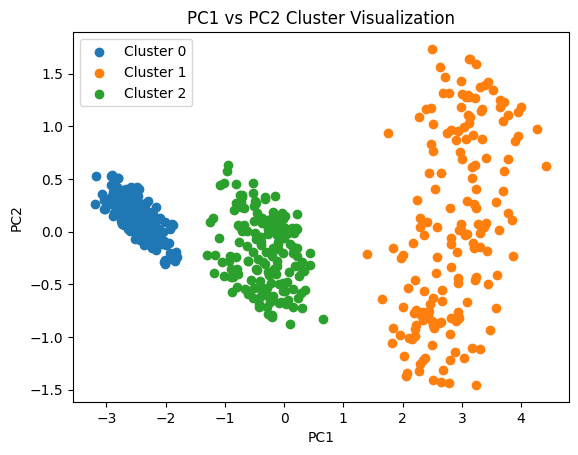

In [6]:
#5 Cluster Visualisation

import matplotlib.pyplot as plt

plt.figure()

for cluster in range(optimal_k):
    plt.scatter(
        X_pca[df['cluster'] == cluster, 0],
        X_pca[df['cluster'] == cluster, 1],
        label=f'Cluster {cluster}'
    )

plt.title('PC1 vs PC2 Cluster Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()
